<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
## Custom embedddings con Gensim



### Objetivo
El objetivo es utilizar documentos / corpus para crear embeddings de palabras basado en ese contexto. Se utilizará canciones de bandas para generar los embeddings, es decir, que los vectores tendrán la forma en función de como esa banda haya utilizado las palabras en sus canciones.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
import multiprocessing
try:
  from gensim.models import Word2Vec
except:
  !pip install gensim
  from gensim.models import Word2Vec

### Datos
Utilizaremos como dataset canciones de bandas de habla inglesa.

In [2]:
# Descargar la carpeta de dataset
import os
import platform
if os.access('./songs_dataset', os.F_OK) is False:
    if os.access('songs_dataset.zip', os.F_OK) is False:
        if platform.system() == 'Windows':
            !curl https://raw.githubusercontent.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/main/datasets/songs_dataset.zip -o songs_dataset.zip
        else:
            !wget songs_dataset.zip https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/raw/main/datasets/songs_dataset.zip
    !unzip -q songs_dataset.zip
else:
    print("El dataset ya se encuentra descargado")

El dataset ya se encuentra descargado


In [3]:
# Posibles bandas
os.listdir("./songs_dataset/")

['prince.txt',
 'dickinson.txt',
 'notorious-big.txt',
 'beatles.txt',
 'bob-dylan.txt',
 'bjork.txt',
 'johnny-cash.txt',
 'disney.txt',
 'janisjoplin.txt',
 'kanye.txt',
 'bob-marley.txt',
 'leonard-cohen.txt',
 'ludacris.txt',
 'adele.txt',
 'alicia-keys.txt',
 'joni-mitchell.txt',
 'amy-winehouse.txt',
 'lorde.txt',
 'rihanna.txt',
 'Kanye_West.txt',
 'nirvana.txt',
 'cake.txt',
 'bieber.txt',
 'notorious_big.txt',
 'missy-elliott.txt',
 'dolly-parton.txt',
 'jimi-hendrix.txt',
 'michael-jackson.txt',
 'al-green.txt',
 'lil-wayne.txt',
 'lady-gaga.txt',
 'lin-manuel-miranda.txt',
 'nursery_rhymes.txt',
 'dj-khaled.txt',
 'radiohead.txt',
 'patti-smith.txt',
 'blink-182.txt',
 'Lil_Wayne.txt',
 'dr-seuss.txt',
 'r-kelly.txt',
 'drake.txt',
 'britney-spears.txt',
 'bruce-springsteen.txt',
 'nicki-minaj.txt',
 'kanye-west.txt',
 'paul-simon.txt',
 'nickelback.txt',
 'eminem.txt',
 'bruno-mars.txt']

In [4]:
# Armar el dataset utilizando salto de línea para separar las oraciones/docs
df = pd.read_csv('songs_dataset/beatles.txt', sep='/n', header=None)
df.head()

/var/folders/2n/z6tnm_t91y339vgqbj9n9hpm0000gn/T/ipykernel_54630/3849064916.py:2: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  df = pd.read_csv('songs_dataset/beatles.txt', sep='/n', header=None)


,0
0,"Yesterday, all my troubles seemed so far away"
1,Now it looks as though they're here to stay
2,"Oh, I believe in yesterday Suddenly, I'm not h..."
3,There's a shadow hanging over me.
4,"Oh, yesterday came suddenly Why she had to go ..."


In [5]:
print("Cantidad de documentos:", df.shape[0])

Cantidad de documentos: 1846


### 1 - Preprocesamiento

In [6]:
from tensorflow.keras.preprocessing.text import text_to_word_sequence

sentence_tokens = []
# Recorrer todas las filas y transformar las oraciones
# en una secuencia de palabras (esto podría realizarse con NLTK o spaCy también)
for _, row in df[:None].iterrows():
    sentence_tokens.append(text_to_word_sequence(row[0]))

In [7]:
# Demos un vistazo
sentence_tokens[:2]

[['yesterday', 'all', 'my', 'troubles', 'seemed', 'so', 'far', 'away'],
 ['now', 'it', 'looks', 'as', 'though', "they're", 'here', 'to', 'stay']]

### 2 - Crear los vectores (word2vec)

In [8]:
from gensim.models.callbacks import CallbackAny2Vec
# Durante el entrenamiento gensim por defecto no informa el "loss" en cada época
# Sobrecargamos el callback para poder tener esta información
class callback(CallbackAny2Vec):
    """
    Callback to print loss after each epoch
    """
    def __init__(self):
        self.epoch = 0

    def on_epoch_end(self, model):
        loss = model.get_latest_training_loss()
        if self.epoch == 0:
            print('Loss after epoch {}: {}'.format(self.epoch, loss))
        else:
            print('Loss after epoch {}: {}'.format(self.epoch, loss- self.loss_previous_step))
        self.epoch += 1
        self.loss_previous_step = loss

In [9]:
# Crearmos el modelo generador de vectores
# En este caso utilizaremos la estructura modelo Skipgram
w2v_model = Word2Vec(min_count=5,    # frecuencia mínima de palabra para incluirla en el vocabulario
                     window=2,       # cant de palabras antes y desp de la predicha
                     vector_size=300,       # dimensionalidad de los vectores
                     negative=20,    # cantidad de negative samples... 0 es no se usa
                     workers=1,      # si tienen más cores pueden cambiar este valor
                     sg=1)           # modelo 0:CBOW  1:skipgram

In [10]:
# Obtener el vocabulario con los tokens
w2v_model.build_vocab(sentence_tokens)

In [11]:
# Cantidad de filas/docs encontradas en el corpus
print("Cantidad de docs en el corpus:", w2v_model.corpus_count)

Cantidad de docs en el corpus: 1846


In [12]:
# Cantidad de words encontradas en el corpus
print("Cantidad de words distintas en el corpus:", len(w2v_model.wv.index_to_key))

Cantidad de words distintas en el corpus: 445


### 3 - Entrenar embeddings

In [13]:
# Entrenamos el modelo generador de vectores
# Utilizamos nuestro callback
w2v_model.train(sentence_tokens,
                 total_examples=w2v_model.corpus_count,
                 epochs=20,
                 compute_loss = True,
                 callbacks=[callback()]
                 )

Loss after epoch 0: 113045.28125
Loss after epoch 1: 65966.59375
Loss after epoch 2: 65934.921875
Loss after epoch 3: 65718.390625
Loss after epoch 4: 63875.125
Loss after epoch 5: 64160.90625
Loss after epoch 6: 64080.375
Loss after epoch 7: 64814.96875
Loss after epoch 8: 62632.6875
Loss after epoch 9: 60452.6875
Loss after epoch 10: 59840.125
Loss after epoch 11: 58884.0625
Loss after epoch 12: 57716.0625
Loss after epoch 13: 56493.875
Loss after epoch 14: 55817.5
Loss after epoch 15: 55842.9375
Loss after epoch 16: 51722.625
Loss after epoch 17: 49858.125
Loss after epoch 18: 49592.0
Loss after epoch 19: 48960.375


(156986, 287740)

### 4 - Ensayar

In [14]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["darling"], topn=10)

[('pretty', 0.8954241275787354),
 ('sleep', 0.8665648102760315),
 ('help', 0.8439377546310425),
 ('cry', 0.8351278305053711),
 ('not', 0.8309565782546997),
 ('try', 0.8276928067207336),
 ('peace', 0.8144847750663757),
 ('little', 0.8140541911125183),
 ('twist', 0.8123903870582581),
 ('seems', 0.8079550862312317)]

In [15]:
# Palabras que MENOS se relacionan con...:
w2v_model.wv.most_similar(negative=["love"], topn=10)

[('shake', -0.22872473299503326),
 ('four', -0.2330225110054016),
 ('five', -0.23746483027935028),
 ('six', -0.23784109950065613),
 ('bang', -0.24832148849964142),
 ('our', -0.25538331270217896),
 ('day', -0.2689809501171112),
 ('going', -0.26920315623283386),
 ('here', -0.2699021100997925),
 ('three', -0.28389549255371094)]

In [16]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["four"], topn=10)

[('five', 0.9813734292984009),
 ('three', 0.9745770692825317),
 ('six', 0.9710827469825745),
 ('seven', 0.9584391713142395),
 ('two', 0.9517229795455933),
 ('sixty', 0.8990437388420105),
 ('one', 0.7951188087463379),
 ('crying', 0.7946332693099976),
 ('us', 0.7740050554275513),
 ("i'm", 0.7508416175842285)]

In [17]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["money"], topn=5)

[("can't", 0.9434012770652771),
 ('buy', 0.9397005438804626),
 ('much', 0.9033158421516418),
 ('just', 0.8509080410003662),
 ('hide', 0.8355337381362915)]

In [18]:
# Ensayar con una palabra que no está en el vocabulario:
#w2v_model.wv.most_similar(negative=["diedaa"])

In [19]:
# el método `get_vector` permite obtener los vectores:
vector_love = w2v_model.wv.get_vector("love")
print(vector_love)

[ 0.06138405  0.058809   -0.06370325  0.02445593 -0.20152055 -0.18612228
 -0.15284562  0.45487782 -0.04217936  0.03536211  0.13657948 -0.18519847
 -0.18126771  0.2214913  -0.3038063  -0.23970455  0.07094643 -0.05679133
 -0.05166036 -0.23843044 -0.08529771  0.195644   -0.07679128  0.03796851
  0.07516617 -0.04825819  0.07379003  0.10396867  0.00737886 -0.22764948
 -0.04567026  0.12936729  0.27786148  0.19387393 -0.13509513  0.20856662
  0.40916505 -0.00386539 -0.10631859 -0.09057057  0.02400651 -0.08005195
  0.1340099   0.08833113 -0.01894911  0.08592594 -0.15906131  0.10259284
  0.14459819 -0.12092229 -0.279187   -0.0406201   0.11382356  0.31366625
 -0.07409906  0.13977523  0.22791535  0.13209976 -0.01811203  0.0977301
  0.09249622 -0.14872141 -0.16348357 -0.13202755 -0.09834751  0.02714126
  0.16531599  0.26052776 -0.03259096 -0.02894498  0.11620875 -0.06974296
  0.09563834 -0.15276456  0.22071241  0.1599668   0.15890227 -0.04711496
 -0.12555523 -0.03993179 -0.10795247  0.01879167  0.

In [20]:
# el método `most_similar` también permite comparar a partir de vectores
w2v_model.wv.most_similar(vector_love)

[('love', 0.9999999403953552),
 ('babe', 0.9085148572921753),
 ('someone', 0.8886125683784485),
 ('need', 0.8827983736991882),
 ('nothing', 0.8740253448486328),
 ("didn't", 0.8638355135917664),
 ("there's", 0.8526684641838074),
 ('you', 0.8456717729568481),
 ('feed', 0.8445045351982117),
 ('somebody', 0.8362783193588257)]

In [21]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["love"], topn=10)

[('babe', 0.9085148572921753),
 ('someone', 0.8886125683784485),
 ('need', 0.8827983736991882),
 ('nothing', 0.8740253448486328),
 ("didn't", 0.8638355135917664),
 ("there's", 0.8526684641838074),
 ('you', 0.8456718921661377),
 ('feed', 0.8445045351982117),
 ('somebody', 0.8362783193588257),
 ('buy', 0.8351733088493347)]

### 5 - Visualizar agrupación de vectores

In [22]:
from sklearn.decomposition import IncrementalPCA
from sklearn.manifold import TSNE
import numpy as np

def reduce_dimensions(model, num_dimensions = 2 ):

    vectors = np.asarray(model.wv.vectors)
    labels = np.asarray(model.wv.index_to_key)

    tsne = TSNE(n_components=num_dimensions, random_state=0)
    vectors = tsne.fit_transform(vectors)

    return vectors, labels

In [23]:
# Graficar los embedddings en 2D
import plotly.graph_objects as go
import plotly.express as px

vecs, labels = reduce_dimensions(w2v_model)

MAX_WORDS=200
fig = px.scatter(x=vecs[:MAX_WORDS,0], y=vecs[:MAX_WORDS,1], text=labels[:MAX_WORDS])
fig.show(renderer="colab") # esto para plotly en colab

In [24]:
# Graficar los embedddings en 3D

vecs, labels = reduce_dimensions(w2v_model,3)

fig = px.scatter_3d(x=vecs[:MAX_WORDS,0], y=vecs[:MAX_WORDS,1], z=vecs[:MAX_WORDS,2],text=labels[:MAX_WORDS])
fig.update_traces(marker_size = 2)
fig.show(renderer="colab") # esto para plotly en colab

In [25]:
# También se pueden guardar los vectores y labels como tsv para graficar en
# http://projector.tensorflow.org/


vectors = np.asarray(w2v_model.wv.vectors)
labels = list(w2v_model.wv.index_to_key)

np.savetxt("vectors.tsv", vectors, delimiter="\t")

with open("labels.tsv", "w") as fp:
    for item in labels:
        fp.write("%s\n" % item)

### Consigna del desafío 2

**Cada experimento realizado debe estar acompañado de una explicación o interpretación de lo observado**

Recuerden que su notebook de entrega debe poder correrse de inicio a fin sin la aparición de errores.

- Crear sus propios vectores con Gensim basado en lo visto en clase con un corpus propio (revisar enlaces sugeridos en clase 2 sobre opciones de dataset)

In [26]:
import os
import pandas as pd
import numpy as np
import plotly.express as px
from sklearn.manifold import TSNE
from tensorflow.keras.preprocessing.text import text_to_word_sequence
from gensim.models import Word2Vec
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
df_own = pd.read_csv('songs_dataset/johnny-cash.txt', sep='/n', header=None, engine='python')
print("Cantidad de documentos (versos) en el nuevo corpus:", df_own.shape[0])

sentence_tokens_own = []
for _, row in df_own.iterrows():
    seq = text_to_word_sequence(str(row[0]))
    if seq:
        seq_filtrada = [palabra for palabra in seq if palabra not in ENGLISH_STOP_WORDS]
        
        if len(seq_filtrada) > 0:
            sentence_tokens_own.append(seq_filtrada)

w2v_own_model = Word2Vec(min_count=3,     # Frecuencia mínima para adaptar a las palabras raras del artista
                         window=3,        # Ventana de contexto alrededor de la palabra objetivo
                         vector_size=150, # Dimensionalidad compacta para el tamaño de las líricas
                         negative=15,     # Muestreo negativo (Negative Sampling) óptimo para regularización
                         workers=1,       # Para garantizar reproducibilidad exacta
                         sg=1)            # Arquitectura Skip-Gram

w2v_own_model.build_vocab(sentence_tokens_own)
print("Cantidad de palabras distintas en el corpus propio:", len(w2v_own_model.wv.index_to_key))

w2v_own_model.train(sentence_tokens_own,
                    total_examples=w2v_own_model.corpus_count,
                    epochs=30,
                    compute_loss=True)

Cantidad de documentos (versos) en el nuevo corpus: 1935
Cantidad de palabras distintas en el corpus propio: 702


(160017, 248610)

- Elegir términos de interés y buscar términos más similares y menos similares.

In [27]:
terminos_interes = ["rain", "world", "man"]

for termino in terminos_interes:
    if termino in w2v_own_model.wv:
        print(f"\n==========================================================")
        print(f"ANÁLISIS COMPLETO PARA EL TÉRMINO: '{termino.upper()}'")
        print(f"==========================================================")
        
        similares = w2v_own_model.wv.most_similar(positive=[termino], topn=5)
        print("Palabras MÁS similares (Cercanía semántica en el contexto del artista):")
        for palabra, score in similares:
            print(f"  -> '{palabra}': {score:.4f}")
            
        print("-" * 58)
        
        opuestos = w2v_own_model.wv.most_similar(negative=[termino], topn=5)
        print("Palabras MENOS similares (Mayor distancia geométrica/contextos opuestos):")
        for palabra, score in opuestos:
            print(f"  -> '{palabra}': {score:.4f}")
    else:
        print(f"\nEl término '{termino}' no se encuentra en el vocabulario del modelo.")


ANÁLISIS COMPLETO PARA EL TÉRMINO: 'RAIN'
Palabras MÁS similares (Cercanía semántica en el contexto del artista):
  -> 'goes': 0.9663
  -> 'south': 0.9627
  -> 'hands': 0.9509
  -> 'rolled': 0.9508
  -> 'drawing': 0.9497
----------------------------------------------------------
Palabras MENOS similares (Mayor distancia geométrica/contextos opuestos):
  -> 'sip': 0.1384
  -> 'danger': 0.0255
  -> 'biter': 0.0183
  -> 'lady': -0.1332
  -> 'ira': -0.4864

ANÁLISIS COMPLETO PARA EL TÉRMINO: 'WORLD'
Palabras MÁS similares (Cercanía semántica en el contexto del artista):
  -> 'hill': 0.9851
  -> 'brave': 0.9841
  -> 'gather': 0.9825
  -> 'sent': 0.9819
  -> 'mud': 0.9818
----------------------------------------------------------
Palabras MENOS similares (Mayor distancia geométrica/contextos opuestos):
  -> 'sip': 0.1158
  -> 'biter': 0.0321
  -> 'danger': 0.0095
  -> 'lady': -0.0931
  -> 'green': -0.5592

ANÁLISIS COMPLETO PARA EL TÉRMINO: 'MAN'
Palabras MÁS similares (Cercanía semántica e

- Realizar una reduccion de dimensionalidad a los embeddings, llevándolos a 2 dimensiones. Graficar los embeddings proyectados y seleccionar una cantidad de términos (variable MAX_WORDS) de forma tal que la visualización sea adecuada.


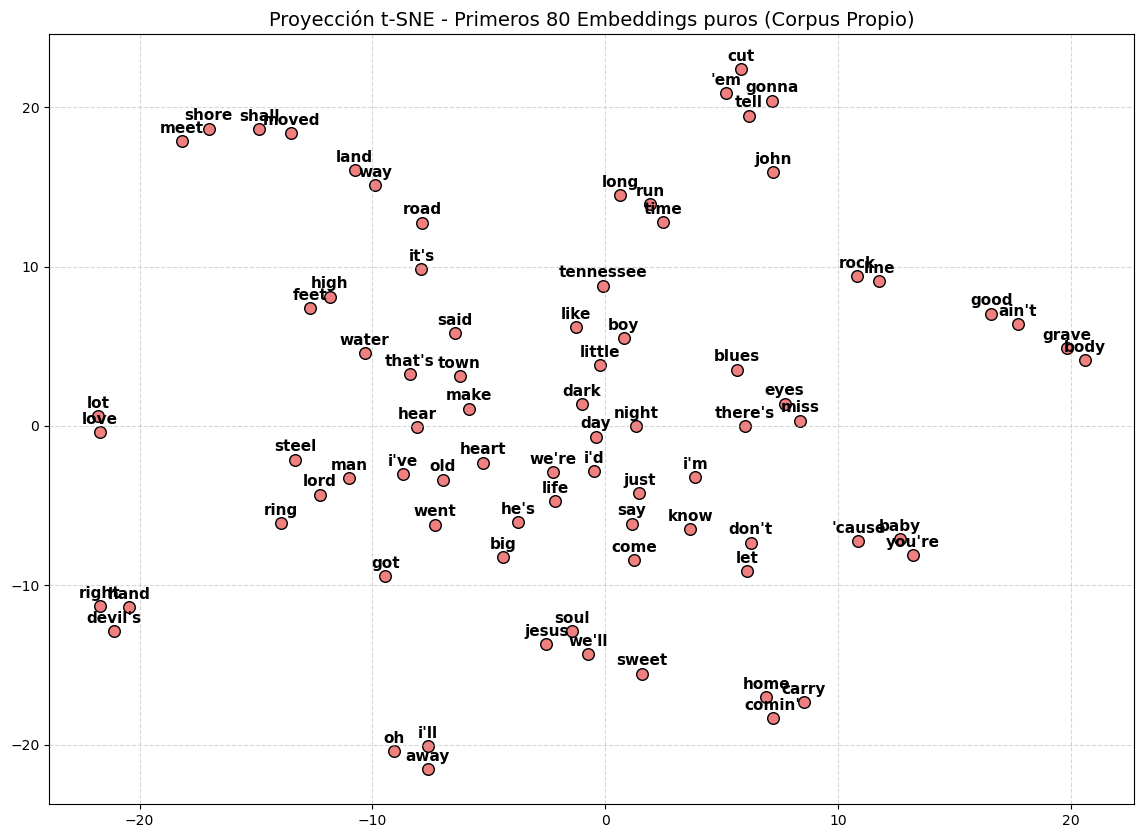

In [29]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

vectores_propios = w2v_own_model.wv.vectors
palabras_propias = w2v_own_model.wv.index_to_key

MAX_WORDS = 80

tsne = TSNE(n_components=2, perplexity=8, init='random', learning_rate='auto', random_state=42, n_iter=2500)
vectores_2d = tsne.fit_transform(vectores_propios[:MAX_WORDS])

fig, ax = plt.subplots(figsize=(14, 10))

ax.scatter(vectores_2d[:, 0], vectores_2d[:, 1], edgecolors='k', c='lightcoral', s=70)

for i, palabra in enumerate(palabras_propias[:MAX_WORDS]):
    ax.annotate(palabra, 
                xy=(vectores_2d[i, 0], vectores_2d[i, 1]), 
                textcoords="offset points", 
                xytext=(0, 6), 
                ha='center', 
                fontsize=11, 
                fontweight='semibold')

ax.set_title(f"Proyección t-SNE - Primeros {MAX_WORDS} Embeddings puros (Corpus Propio)", fontsize=14)
ax.grid(True, linestyle='--', alpha=0.5)
plt.show()

- Inspeccionar el grafico y buscar pequeños grupos de palabras que puedan formarse. Interpretarlos e intentar obtener conclusiones. En lo posible, acompañar los grupos de palabras con capturas (y pegarlas en celdas de texto)

## Grupo 1: Tiempo
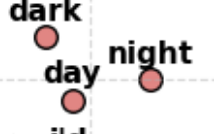

## Grupo 2: Sentimiento

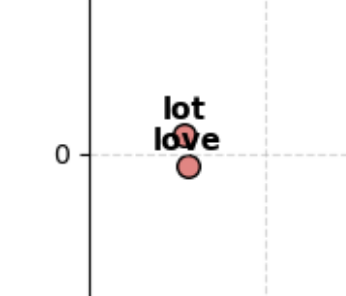

## Grupo 3: Desplazamiento

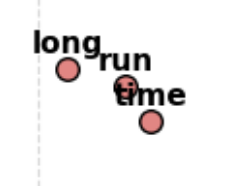